# Diabetes Prediction using Machine Learning

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import pickle

In [2]:
!pip install ipykernel

In [3]:
# Load dataset
data = pd.read_csv('../Dataset/diabetes.csv')
print(data.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [4]:
print(data.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

In [5]:
print(data.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


We can see there few data for columns Glucose , Insulin, skin thickenss, BMI and Blood Pressure which have value as 0. That's not possible,right? you can do a quick search to see that one cannot have 0 values for these.
Let's deal with that. we can either remove such data or simply replace it with their respective mean values.
Let's do the latter.

In [6]:
#Here few misconception is there lke BMI can not be zero, BP can't be zero, glucose, insuline can't be zero so lets try to fix it.
# Replacing invalid zero values with the mean of the column

columns_with_zero_invalid = ['BMI','BloodPressure','Glucose','Insulin','SkinThickness']

for col in columns_with_zero_invalid:
    data[col] = data[col].replace(0, data[col].mean())

print(data.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  121.681605      72.254807      26.606479  118.660163   
std       3.369578   30.436016      12.115932       9.631241   93.080358   
min       0.000000   44.000000      24.000000       7.000000   14.000000   
25%       1.000000   99.750000      64.000000      20.536458   79.799479   
50%       3.000000  117.000000      72.000000      23.000000   79.799479   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    32.450805                  0.471876   33.240885    0.348958  
std      6.875374                  0.331329   11.760232    0.476951  
min     18.200000                  

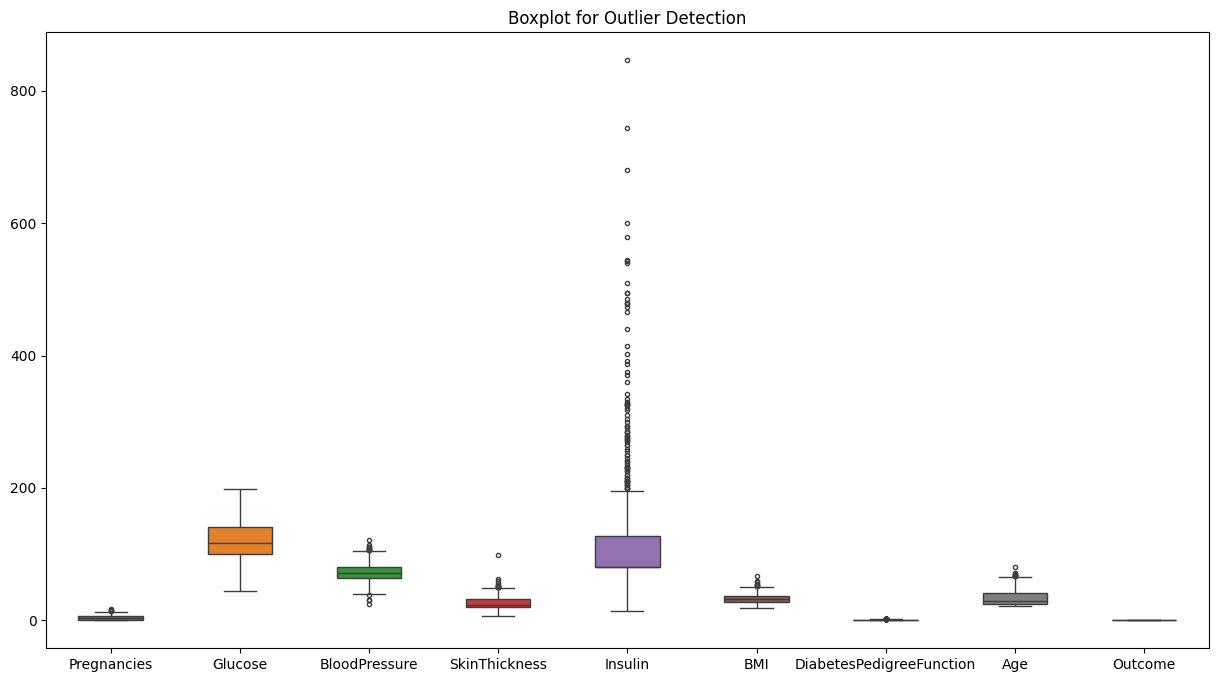

In [7]:
#now we have dealt with the 0 values and data looks better. But, there still are outliers present in some columns.lets visualize it
plt.figure(figsize=(15,8))
sns.boxplot(data=data, width=0.5, fliersize=3)
plt.title('Boxplot for Outlier Detection')
plt.show()

In [8]:
print(data.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness     Insulin   BMI  \
0            6    148.0           72.0      35.000000   79.799479  33.6   
1            1     85.0           66.0      29.000000   79.799479  26.6   
2            8    183.0           64.0      20.536458   79.799479  23.3   
3            1     89.0           66.0      23.000000   94.000000  28.1   
4            0    137.0           40.0      35.000000  168.000000  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [9]:
#segregate the dependent and independent variable
X = data.drop(columns = ['Outcome'])
y = data['Outcome']

In [10]:
# separate dataset into train and test split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=0)
print(X_train.shape, X_test.shape)

(576, 8) (192, 8)


In [11]:
#standard Scaling- Standardization

def scaler_standard(X_train, X_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    with open('../Model/standardScalar.pkl', 'wb') as f:
        pickle.dump(scaler, f)

    return X_train_scaled, X_test_scaled

X_train_scaled, X_test_scaled = scaler_standard(X_train, X_test)

In [12]:
# Logistic Regression with Hyperparameter Tuning
# Hyperparameter Tuning using GridSearchCV
log_params = {
'penalty': ['l1','l2'],
'C': np.logspace(-3,3,7),
'solver': ['newton-cg', 'lbfgs', 'liblinear']
}


log_reg = LogisticRegression()
log_clf = GridSearchCV(log_reg, log_params, scoring='accuracy', cv=10)
log_clf.fit(X_train_scaled, y_train)


print("Best Parameters (Logistic Regression):", log_clf.best_params_)
print("Best Accuracy (Training):", log_clf.best_score_)

Best Parameters (Logistic Regression): {'C': np.float64(1.0), 'penalty': 'l2', 'solver': 'liblinear'}
Best Accuracy (Training): 0.763793103448276


In [14]:
# Train Other ML Models for Comparison

models = {
    'Random Forest': RandomForestClassifier(),
    'SVM (RBF Kernel)': SVC(),
    'KNN': KNeighborsClassifier()
}

results = {}

for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    results[model_name] = acc
    print(f"\nModel: {model_name}")
    print(f"Accuracy: {acc}")
    print(confusion_matrix(y_test, preds))
    print(classification_report(y_test, preds))


Model: Random Forest
Accuracy: 0.796875
[[115  15]
 [ 24  38]]
              precision    recall  f1-score   support

           0       0.83      0.88      0.86       130
           1       0.72      0.61      0.66        62

    accuracy                           0.80       192
   macro avg       0.77      0.75      0.76       192
weighted avg       0.79      0.80      0.79       192


Model: SVM (RBF Kernel)
Accuracy: 0.7552083333333334
[[115  15]
 [ 32  30]]
              precision    recall  f1-score   support

           0       0.78      0.88      0.83       130
           1       0.67      0.48      0.56        62

    accuracy                           0.76       192
   macro avg       0.72      0.68      0.70       192
weighted avg       0.74      0.76      0.74       192


Model: KNN
Accuracy: 0.78125
[[114  16]
 [ 26  36]]
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       130
           1       0.69      0.58      0.63

In [16]:
# Evaluate Logistic Regression on Test Data

y_pred = log_clf.predict(X_test_scaled)


conf_mat = confusion_matrix(y_test, y_pred)
print(conf_mat)


true_positive = conf_mat[0][0]
false_positive = conf_mat[0][1]
false_negative = conf_mat[1][0]
true_negative = conf_mat[1][1]


Accuracy = (true_positive + true_negative) / (true_positive + false_positive + false_negative + true_negative)
Precision = true_positive / (true_positive + false_positive)
Recall = true_positive / (true_positive + false_negative)
F1_Score = 2 * (Recall * Precision) / (Recall + Precision)


print("Accuracy:", Accuracy)
print("Precision:", Precision)
print("Recall:", Recall)
print("F1 Score:", F1_Score)

[[117  13]
 [ 26  36]]
Accuracy: 0.796875
Precision: 0.9
Recall: 0.8181818181818182
F1 Score: 0.8571428571428572


In [17]:
# Save Best Model (Based on Accuracy)

best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print(f"Best Performing Model: {best_model_name} with accuracy {results[best_model_name]}")

# Save Best Model
with open('../Model/bestModel.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save Logistic Regression (Tuned)
with open('../Model/logisticModel.pkl', 'wb') as f:
    pickle.dump(log_clf, f)

print("Models Saved Successfully!")


Best Performing Model: Random Forest with accuracy 0.796875
Models Saved Successfully!
